In [1]:
import json
import os
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import List, Dict, Tuple
import pandas as pd

class MicroorganismPatcher:
    def __init__(self, images_dir: str, annotations_file: str, species_csv: str, output_dir: str, 
                 patch_size: int = 1024, overlap: int = 128):
        """
        Découpe les images de Gram en patches et ajuste les annotations avec classification
        
        Args:
            images_dir: Dossier contenant les images originales
            annotations_file: Fichier JSON avec les annotations
            species_csv: Fichier CSV avec la correspondance prefix -> species
            output_dir: Dossier de sortie pour les patches
            patch_size: Taille des patches (défaut: 1024x1024)
            overlap: Chevauchement entre patches en pixels (défaut: 128)
        """
        self.images_dir = Path(images_dir)
        self.annotations_file = Path(annotations_file)
        self.species_csv = Path(species_csv)
        self.output_dir = Path(output_dir)
        self.patch_size = patch_size
        self.overlap = overlap
        
        # Créer les dossiers de sortie
        self.patches_dir = self.output_dir / "patches"
        self.patches_dir.mkdir(parents=True, exist_ok=True)
        
        # Charger le fichier CSV des espèces
        print("Chargement du fichier CSV des espèces...")
        self.species_df = pd.read_csv(self.species_csv)
        print(f"✓ {len(self.species_df)} lignes chargées")
        print(f"✓ {self.species_df['prefix'].nunique()} préfixes uniques trouvés")
        
        # Créer un dictionnaire prefix -> species info
        self.prefix_to_species = {}
        for _, row in self.species_df.iterrows():
            prefix = row['prefix'].lower()
            if prefix not in self.prefix_to_species:
                self.prefix_to_species[prefix] = {
                    'species': row['species'],
                    'gram': row['gram'],
                    'morphology': row['morphology']
                }
        
        print(f"\n📋 Correspondances prefix -> espèce:")
        for prefix, info in sorted(self.prefix_to_species.items()):
            print(f"  {prefix} → {info['species']} ({info['gram']}, {info['morphology']})")
        
        # Charger les annotations
        print("\nChargement des annotations...")
        with open(self.annotations_file, 'r') as f:
            self.data = json.load(f)
        
        print(f"✓ {len(self.data.get('images', []))} images trouvées")
        print(f"✓ {len(self.data.get('annotations', []))} annotations trouvées")
        print(f"✓ {len(self.data.get('categories', []))} catégories trouvées")
    
    def extract_prefix_from_filename(self, filename: str) -> str:
        """Extrait le préfixe du nom de fichier"""
        base_name = Path(filename).stem
        parts = base_name.split('_')
        if len(parts) > 0:
            return parts[0].lower()
        return ""
    
    def get_species_info(self, filename: str) -> Dict:
        """Récupère les informations sur l'espèce à partir du nom de fichier"""
        prefix = self.extract_prefix_from_filename(filename)
        
        if prefix in self.prefix_to_species:
            return self.prefix_to_species[prefix]
        else:
            print(f"  Préfixe '{prefix}' non trouvé dans le CSV pour {filename}")
            return {
                'species': 'Unknown',
                'gram': 'unknown',
                'morphology': 'unknown'
            }
    
    def calculate_patches(self, width: int, height: int) -> List[Tuple[int, int, int, int]]:
        """Calcule les coordonnées de tous les patches pour une image"""
        patches = []
        stride = self.patch_size - self.overlap
        
        n_patches_x = math.ceil((width - self.overlap) / stride)
        n_patches_y = math.ceil((height - self.overlap) / stride)
        
        for i in range(n_patches_y):
            for j in range(n_patches_x):
                x1 = j * stride
                y1 = i * stride
                x2 = min(x1 + self.patch_size, width)
                y2 = min(y1 + self.patch_size, height)
                
                if x2 - x1 < self.patch_size and x2 == width:
                    x1 = max(0, width - self.patch_size)
                if y2 - y1 < self.patch_size and y2 == height:
                    y1 = max(0, height - self.patch_size)
                
                patches.append((x1, y1, x2, y2))
        
        return patches
    
    def apply_random_zoom(self, image: Image.Image, annotations: List[Dict], 
                         zoom_range: Tuple[float, float] = (1.0, 1.5)) -> Tuple[Image.Image, List[Dict]]:
        """
        Applique un zoom aléatoire sur l'image et ajuste les annotations
        
        Args:
            image: Image PIL
            annotations: Liste des annotations
            zoom_range: (zoom_min, zoom_max) - 1.0 = pas de zoom, 1.5 = zoom 150%
        
        Returns:
            image_zoomée, annotations_ajustées
        """
        zoom_factor = random.uniform(zoom_range[0], zoom_range[1])
        
        # Si zoom_factor = 1.0, pas de zoom
        if zoom_factor == 1.0:
            return image, annotations
        
        width, height = image.size
        
        # Nouvelle taille après zoom
        new_width = int(width * zoom_factor)
        new_height = int(height * zoom_factor)
        
        # Redimensionner l'image (zoom)
        zoomed_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
        
        # Calculer le crop pour revenir à la taille originale (crop centré)
        left = (new_width - width) // 2
        top = (new_height - height) // 2
        right = left + width
        bottom = top + height
        
        # Cropper pour garder la taille originale
        final_image = zoomed_image.crop((left, top, right, bottom))
        
        # Ajuster les annotations
        adjusted_annotations = []
        for ann in annotations:
            adj_ann = ann.copy()
            
            # Ajuster bbox
            if 'bbox' in ann:
                x, y, w, h = ann['bbox']
                
                # Appliquer le zoom
                new_x = x * zoom_factor - left
                new_y = y * zoom_factor - top
                new_w = w * zoom_factor
                new_h = h * zoom_factor
                
                # Vérifier si la bbox est encore dans l'image
                if new_x + new_w > 0 and new_y + new_h > 0 and new_x < width and new_y < height:
                    # Clipper aux limites
                    new_x = max(0, new_x)
                    new_y = max(0, new_y)
                    new_w = min(new_w, width - new_x)
                    new_h = min(new_h, height - new_y)
                    
                    # Vérifier que la bbox a une taille raisonnable
                    if new_w > 5 and new_h > 5:  # Au moins 5x5 pixels
                        adj_ann['bbox'] = [new_x, new_y, new_w, new_h]
                        adj_ann['area'] = new_w * new_h
                        
                        # Ajuster segmentation si présente
                        if 'segmentation' in ann and ann['segmentation']:
                            new_segmentation = []
                            for seg in ann['segmentation']:
                                new_seg = []
                                for i in range(0, len(seg), 2):
                                    seg_x = seg[i] * zoom_factor - left
                                    seg_y = seg[i + 1] * zoom_factor - top
                                    
                                    # Clipper
                                    seg_x = max(0, min(seg_x, width))
                                    seg_y = max(0, min(seg_y, height))
                                    new_seg.extend([seg_x, seg_y])
                                new_segmentation.append(new_seg)
                            adj_ann['segmentation'] = new_segmentation
                        
                        adjusted_annotations.append(adj_ann)
        
        return final_image, adjusted_annotations
    
    def bbox_intersects_patch(self, bbox: List[float], patch_coords: Tuple[int, int, int, int], 
                            min_overlap_ratio: float = 0.5) -> bool:
        """Vérifie si une bbox intersecte suffisamment avec un patch"""
        x1_patch, y1_patch, x2_patch, y2_patch = patch_coords
        x_obj, y_obj, w_obj, h_obj = bbox
        
        x1_obj = x_obj
        y1_obj = y_obj
        x2_obj = x_obj + w_obj
        y2_obj = y_obj + h_obj
        
        x1_inter = max(x1_patch, x1_obj)
        y1_inter = max(y1_patch, y1_obj)
        x2_inter = min(x2_patch, x2_obj)
        y2_inter = min(y2_patch, y2_obj)
        
        if x1_inter >= x2_inter or y1_inter >= y2_inter:
            return False
        
        intersection_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
        object_area = w_obj * h_obj
        overlap_ratio = intersection_area / object_area if object_area > 0 else 0
        
        return overlap_ratio >= min_overlap_ratio
    
    def adjust_annotation_to_patch(self, annotation: Dict, patch_coords: Tuple[int, int, int, int]) -> Dict:
        """Ajuste les coordonnées de l'annotation par rapport au patch"""
        x1_patch, y1_patch, x2_patch, y2_patch = patch_coords
        adjusted_ann = annotation.copy()
        
        if 'bbox' in annotation:
            x, y, w, h = annotation['bbox']
            
            new_x = x - x1_patch
            new_y = y - y1_patch
            
            new_x = max(0, new_x)
            new_y = max(0, new_y)
            new_w = min(w, (x2_patch - x1_patch) - new_x)
            new_h = min(h, (y2_patch - y1_patch) - new_y)
            
            adjusted_ann['bbox'] = [new_x, new_y, new_w, new_h]
            adjusted_ann['area'] = new_w * new_h
        
        if 'segmentation' in annotation and annotation['segmentation']:
            new_segmentation = []
            for seg in annotation['segmentation']:
                new_seg = []
                for i in range(0, len(seg), 2):
                    x = seg[i] - x1_patch
                    y = seg[i + 1] - y1_patch
                    
                    x = max(0, min(x, x2_patch - x1_patch))
                    y = max(0, min(y, y2_patch - y1_patch))
                    
                    new_seg.extend([x, y])
                new_segmentation.append(new_seg)
            adjusted_ann['segmentation'] = new_segmentation
        
        return adjusted_ann
    
    def create_species_categories(self) -> List[Dict]:
        """Crée la liste des catégories basée sur les espèces uniques"""
        categories = []
        category_id = 1
        
        unique_species = self.species_df.drop_duplicates(subset=['species'])
        
        for _, row in unique_species.iterrows():
            categories.append({
                'id': category_id,
                'name': row['species'],
                'supercategory': f"{row['gram']}_{row['morphology']}",
                'metadata': {
                    'gram': row['gram'],
                    'morphology': row['morphology'],
                    'prefix': row['prefix']
                }
            })
            category_id += 1
        
        return categories
    
    def get_category_id_for_species(self, species_name: str, categories: List[Dict]) -> int:
        """Trouve l'ID de catégorie pour une espèce donnée"""
        for cat in categories:
            if cat['name'] == species_name:
                return cat['id']
        return 1
    
    def process_images(self, min_overlap_ratio: float = 0.5, 
                      enable_zoom_augmentation: bool = True,
                      zoom_probability: float = 0.5,
                      zoom_range: Tuple[float, float] = (1.0, 1.5)):
        """
        Traite toutes les images et génère les patches avec annotations et classification
        
        Args:
            min_overlap_ratio: Ratio minimum de l'objet dans le patch pour le conserver
            enable_zoom_augmentation: Activer l'augmentation par zoom
            zoom_probability: Probabilité d'appliquer le zoom (0.5 = 50% des patches)
            zoom_range: (zoom_min, zoom_max) - ex: (1.0, 1.5) pour zoom jusqu'à 150%
        """
        new_images = []
        new_annotations = []
        annotation_id = 0
        image_id = 0
        
        stats = {
            'total_patches': 0,
            'patches_with_annotations': 0,
            'total_annotations': 0,
            'images_processed': 0,
            'species_count': {},
            'zoomed_patches': 0
        }
        
        # Créer les catégories basées sur les espèces
        categories = self.create_species_categories()
        print(f"\n🔬 Catégories créées: {len(categories)}")
        for cat in categories:
            print(f"  ID {cat['id']}: {cat['name']} ({cat['supercategory']})")
        
        if enable_zoom_augmentation:
            print(f"\n🔍 Augmentation par ZOOM activée:")
            print(f"  - Probabilité: {zoom_probability*100:.0f}%")
            print(f"  - Range: {zoom_range[0]:.1f}x à {zoom_range[1]:.1f}x")
        
        new_data = {
            "images": [],
            "categories": categories,
            "annotations": []
        }
        
        # Traiter chaque image
        for img_idx, img_info in enumerate(self.data.get("images", [])):
            file_name = img_info['file_name']
            print(f"\n[{img_idx + 1}/{len(self.data['images'])}] Traitement de {file_name}...")
            
            species_info = self.get_species_info(file_name)
            print(f"  Espèce: {species_info['species']} (Gram {species_info['gram']}, {species_info['morphology']})")
            
            category_id = self.get_category_id_for_species(species_info['species'], categories)
            
            img_path = self.images_dir / file_name
            if not img_path.exists():
                print(f"  ⚠️  Image non trouvée: {img_path}")
                continue
            
            try:
                image = Image.open(img_path)
                width, height = image.size
                print(f"  Dimensions: {width}x{height}")
            except Exception as e:
                print(f"  ❌ Erreur lors du chargement: {e}")
                continue
            
            patches = self.calculate_patches(width, height)
            print(f"  → {len(patches)} patches à créer")
            
            image_annotations = [ann for ann in self.data.get("annotations", []) 
                               if ann.get("image_id") == img_info["id"]]
            print(f"  → {len(image_annotations)} annotations dans l'image originale")
            
            # Traiter chaque patch
            for patch_idx, (x1, y1, x2, y2) in enumerate(patches):
                # Découper l'image
                patch_img = image.crop((x1, y1, x2, y2))
                
                # Filtrer les annotations pour ce patch
                patch_annotations = []
                for ann in image_annotations:
                    if self.bbox_intersects_patch(ann['bbox'], (x1, y1, x2, y2), min_overlap_ratio):
                        adjusted_ann = self.adjust_annotation_to_patch(ann, (x1, y1, x2, y2))
                        patch_annotations.append(adjusted_ann)
                
                # Appliquer zoom aléatoire si activé
                is_zoomed = False
                if enable_zoom_augmentation and random.random() < zoom_probability:
                    patch_img, patch_annotations = self.apply_random_zoom(
                        patch_img, patch_annotations, zoom_range
                    )
                    is_zoomed = True
                    stats['zoomed_patches'] += 1
                
                # Nom du fichier patch
                base_name = Path(file_name).stem
                zoom_suffix = "_zoom" if is_zoomed else ""
                patch_name = f"{base_name}_patch_{patch_idx:04d}{zoom_suffix}.jpg"
                patch_path = self.patches_dir / patch_name
                
                # Sauvegarder le patch
                patch_img.save(patch_path, quality=95)
                
                # Créer l'entrée image pour le patch
                patch_img_info = {
                    "id": image_id,
                    "file_name": patch_name,
                    "width": patch_img.width,
                    "height": patch_img.height,
                    "path": str(patch_path),
                    "dataset_id": img_info.get("dataset_id"),
                    "category_ids": [],
                    "annotated": False,
                    "annotating": [],
                    "num_annotations": 0,
                    "metadata": {
                        "original_image_id": img_info["id"],
                        "original_image": file_name,
                        "patch_coords": [x1, y1, x2, y2],
                        "patch_index": patch_idx,
                        "species": species_info['species'],
                        "gram": species_info['gram'],
                        "morphology": species_info['morphology'],
                        "prefix": self.extract_prefix_from_filename(file_name),
                        "zoom_augmented": is_zoomed
                    },
                    "deleted": False,
                    "milliseconds": 0,
                    "events": [],
                    "regenerate_thumbnail": False
                }
                
                # Finaliser les annotations
                final_patch_annotations = []
                for ann in patch_annotations:
                    ann['id'] = annotation_id
                    ann['image_id'] = image_id
                    ann['category_id'] = category_id
                    
                    if 'metadata' not in ann:
                        ann['metadata'] = {}
                    ann['metadata']['species'] = species_info['species']
                    ann['metadata']['gram'] = species_info['gram']
                    ann['metadata']['morphology'] = species_info['morphology']
                    
                    final_patch_annotations.append(ann)
                    annotation_id += 1
                    
                    species_name = species_info['species']
                    if species_name not in stats['species_count']:
                        stats['species_count'][species_name] = 0
                    stats['species_count'][species_name] += 1
                
                # Mettre à jour les métadonnées de l'image
                patch_img_info['num_annotations'] = len(final_patch_annotations)
                if len(final_patch_annotations) > 0:
                    patch_img_info['annotated'] = True
                    patch_img_info['category_ids'] = [category_id]
                    stats['patches_with_annotations'] += 1
                
                new_images.append(patch_img_info)
                new_annotations.extend(final_patch_annotations)
                
                stats['total_patches'] += 1
                stats['total_annotations'] += len(final_patch_annotations)
                
                if len(final_patch_annotations) > 0:
                    zoom_tag = " [ZOOM]" if is_zoomed else ""
                    print(f"    Patch {patch_idx:04d}{zoom_tag}: {len(final_patch_annotations)} microorganismes ({species_info['species']})")
                
                image_id += 1
            
            stats['images_processed'] += 1
            image.close()
        
        # Sauvegarder les nouvelles annotations
        new_data["images"] = new_images
        new_data["annotations"] = new_annotations
        
        output_annotations = self.output_dir / "annotations_patches.json"
        with open(output_annotations, 'w') as f:
            json.dump(new_data, f, indent=2)
        
        # Afficher les statistiques
        print("\n" + "="*60)
        print("  ✅ TRAITEMENT TERMINÉ!")
        print("="*60)
        print(f"Images traitées: {stats['images_processed']}")
        print(f"Patches créés: {stats['total_patches']}")
        if enable_zoom_augmentation:
            print(f"  → Patches avec zoom: {stats['zoomed_patches']} ({stats['zoomed_patches']/stats['total_patches']*100:.1f}%)")
        print(f"Patches avec annotations: {stats['patches_with_annotations']}")
        print(f"Annotations transférées: {stats['total_annotations']}")
        
        print(f"\n📊 DISTRIBUTION PAR ESPÈCE:")
        for species, count in sorted(stats['species_count'].items(), key=lambda x: x[1], reverse=True):
            percentage = (count / stats['total_annotations'] * 100) if stats['total_annotations'] > 0 else 0
            print(f"  {species}: {count} annotations ({percentage:.1f}%)")
        
        print(f"\n💾 Fichiers sauvegardés:")
        print(f"  - Patches: {self.patches_dir}")
        print(f"  - Annotations: {output_annotations}")
        
        return new_data, stats
    
    # ... (le reste des méthodes reste identique: compare_annotations, visualize_random_patches, etc.)
    # Je les garde telles quelles pour ne pas surcharger
    def compare_annotations(self, new_data: Dict):
        """
        Compare le nombre de microorganismes avant et après le patching
        """
        print("\n" + "="*60)
        print("  COMPARAISON DES ANNOTATIONS")
        print("="*60)
        
        # Statistiques originales
        original_images = len(self.data.get("images", []))
        original_annotations = len(self.data.get("annotations", []))
        original_annotated = sum(1 for img in self.data.get("images", []) 
                               if img.get("num_annotations", 0) > 0)
        
        # Statistiques patches
        patch_images = len(new_data.get("images", []))
        patch_annotations = len(new_data.get("annotations", []))
        patch_annotated = sum(1 for img in new_data.get("images", []) 
                            if img.get("num_annotations", 0) > 0)
        
        print("\n📸 IMAGES:")
        print(f"  Avant: {original_images} images")
        print(f"  Après: {patch_images} patches")
        print(f"  Ratio: {patch_images/original_images:.1f}x plus d'images")
        
        print("\n🔬 MICROORGANISMES:")
        print(f"  Avant: {original_annotations} annotations")
        print(f"  Après: {patch_annotations} annotations")
        print(f"  Différence: {patch_annotations - original_annotations:+d} annotations")
        
        if patch_annotations > original_annotations:
            print(f"   Augmentation due au chevauchement (overlap={self.overlap}px)")
            print(f"     Un même microorganisme peut apparaître dans plusieurs patches")
        elif patch_annotations < original_annotations:
            print(f"    Perte d'annotations (probablement aux bords)")
            perte_pct = (original_annotations - patch_annotations) / original_annotations * 100
            print(f"     {perte_pct:.1f}% de microorganismes perdus")
        else:
            print(f"  Aucune annotation perdue!")
        
        print("\nIMAGES ANNOTÉES:")
        print(f"  Avant: {original_annotated}/{original_images} images ({original_annotated/original_images*100:.1f}%)")
        print(f"  Après: {patch_annotated}/{patch_images} patches ({patch_annotated/patch_images*100:.1f}%)")
        
        print("\nDENSITÉ MOYENNE:")
        avg_original = original_annotations / original_images if original_images > 0 else 0
        avg_patches = patch_annotations / patch_images if patch_images > 0 else 0
        print(f"  Avant: {avg_original:.1f} microorganismes/image")
        print(f"  Après: {avg_patches:.1f} microorganismes/patch")
        
        # Distribution par image
        print("\nDISTRIBUTION:")
        original_counts = [img.get("num_annotations", 0) for img in self.data.get("images", [])]
        patch_counts = [img.get("num_annotations", 0) for img in new_data.get("images", [])]
        print(f"  Original - Min: {min(original_counts)}, Max: {max(original_counts)}, Moyenne: {sum(original_counts)/len(original_counts):.1f}")
        print(f"  Patches - Min: {min(patch_counts)}, Max: {max(patch_counts)}, Moyenne: {sum(patch_counts)/len(patch_counts):.1f}")
        
        return {
            "original": {
                "images": original_images,
                "annotations": original_annotations,
                "annotated_images": original_annotated,
                "avg_per_image": avg_original
            },
            "patches": {
                "images": patch_images,
                "annotations": patch_annotations,
                "annotated_images": patch_annotated,
                "avg_per_image": avg_patches
            }
        }
    
    def visualize_random_patches(self, annotations_file: str = None, num_samples: int = 5, 
                                only_annotated: bool = True, save_dir: str = None):
        """
        Visualise aléatoirement des patches avec leurs bounding boxes et labels d'espèce
        
        Args:
            annotations_file: Fichier JSON des patches (si None, utilise le fichier généré)
            num_samples: Nombre de patches à visualiser
            only_annotated: Si True, ne montre que les patches avec annotations
            save_dir: Dossier où sauvegarder les visualisations (optionnel)
        """
        # Charger les annotations des patches
        if annotations_file is None:
            annotations_file = self.output_dir / "annotations_patches.json"
        
        with open(annotations_file, 'r') as f:
            patch_data = json.load(f)
        
        # Créer un mapping category_id -> species name
        category_map = {cat['id']: cat['name'] for cat in patch_data.get('categories', [])}
        
        # Filtrer les images
        images = patch_data.get("images", [])
        if only_annotated:
            images = [img for img in images if img.get("num_annotations", 0) > 0]
        
        if len(images) == 0:
            print("Aucune image à visualiser!")
            return
        
        # Sélectionner aléatoirement
        num_samples = min(num_samples, len(images))
        selected_images = random.sample(images, num_samples)
        
        # Créer le dossier de sauvegarde si nécessaire
        if save_dir:
            save_path = Path(save_dir)
            save_path.mkdir(parents=True, exist_ok=True)
        
        print(f"\n Visualisation de {num_samples} patches aléatoires...")
        
        # Créer la figure
        fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))
        if num_samples == 1:
            axes = [axes]
        
        for idx, (ax, img_info) in enumerate(zip(axes, selected_images)):
            # Charger l'image
            img_path = self.patches_dir / img_info['file_name']
            image = Image.open(img_path)
            
            # Afficher l'image
            ax.imshow(image)
            ax.axis('off')
            
            # Récupérer les annotations pour cette image
            image_annotations = [ann for ann in patch_data.get("annotations", []) 
                               if ann.get("image_id") == img_info["id"]]
            
            # Récupérer l'espèce depuis les métadonnées
            species = img_info['metadata'].get('species', 'Unknown')
            gram = img_info['metadata'].get('gram', '')
            morphology = img_info['metadata'].get('morphology', '')
            
            # Dessiner les bounding boxes
            for ann in image_annotations:
                bbox = ann['bbox']
                x, y, w, h = bbox
                
                # Créer un rectangle
                rect = mpatches.Rectangle(
                    (x, y), w, h,
                    linewidth=2,
                    edgecolor='lime',
                    facecolor='none'
                )
                ax.add_patch(rect)
                
                # Ajouter un label avec l'espèce
                label_text = f"{species}"
                ax.text(x, y-5, label_text,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lime', alpha=0.7),
                       fontsize=8, color='black', weight='bold')
            
            # Titre avec informations sur l'espèce
            original_img = img_info['metadata'].get('original_image', 'unknown')
            patch_idx = img_info['metadata'].get('patch_index', 0)
            title = f"{original_img}\nPatch {patch_idx}\n"
            title += f"{species}\n"
            title += f"({gram}, {morphology})\n"
            title += f"{len(image_annotations)} microorganismes"
            ax.set_title(title, fontsize=9, weight='bold')
        
        plt.tight_layout()
        
        # Sauvegarder ou afficher
        if save_dir:
            save_file = save_path / f"visualization_{random.randint(1000, 9999)}.png"
            plt.savefig(save_file, dpi=150, bbox_inches='tight')
            print(f"✓ Sauvegardé: {save_file}")
        
        plt.show()
    
    def visualize_patch_by_name(self, patch_name: str, annotations_file: str = None):
        """
        Visualise un patch spécifique par son nom avec les labels d'espèce
        
        Args:
            patch_name: Nom du fichier patch (ex: "Bthe_01_patch_0023.jpg")
            annotations_file: Fichier JSON des patches
        """
        # Charger les annotations des patches
        if annotations_file is None:
            annotations_file = self.output_dir / "annotations_patches.json"
        
        with open(annotations_file, 'r') as f:
            patch_data = json.load(f)
        
        # Créer un mapping category_id -> species name
        category_map = {cat['id']: cat['name'] for cat in patch_data.get('categories', [])}
        
        # Trouver l'image
        img_info = None
        for img in patch_data.get("images", []):
            if img['file_name'] == patch_name:
                img_info = img
                break
        
        if img_info is None:
            print(f"Patch '{patch_name}' non trouvé!")
            return
        
        # Charger l'image
        img_path = self.patches_dir / patch_name
        if not img_path.exists():
            print(f"Fichier image non trouvé: {img_path}")
            return
        
        image = Image.open(img_path)
        
        # Créer la figure
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        ax.imshow(image)
        ax.axis('off')
        
        # Récupérer les annotations
        image_annotations = [ann for ann in patch_data.get("annotations", []) 
                           if ann.get("image_id") == img_info["id"]]
        
        # Récupérer les informations sur l'espèce
        species = img_info['metadata'].get('species', 'Unknown')
        gram = img_info['metadata'].get('gram', '')
        morphology = img_info['metadata'].get('morphology', '')
        
        # Dessiner les bounding boxes
        for ann in image_annotations:
            bbox = ann['bbox']
            x, y, w, h = bbox
            
            rect = mpatches.Rectangle(
                (x, y), w, h,
                linewidth=3,
                edgecolor='lime',
                facecolor='none'
            )
            ax.add_patch(rect)
            
            # Label avec espèce
            label_text = f"{species}\nID:{ann['id']}"
            ax.text(x, y-10, label_text,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='lime', alpha=0.8),
                   fontsize=10, color='black', weight='bold')
        
        # Titre détaillé
        original_img = img_info['metadata'].get('original_image', 'unknown')
        patch_idx = img_info['metadata'].get('patch_index', 0)
        coords = img_info['metadata'].get('patch_coords', [0, 0, 0, 0])
        
        title = f"Patch: {patch_name}\n"
        title += f"Image originale: {original_img} (Patch #{patch_idx})\n"
        title += f"Espèce: {species} (Gram {gram}, {morphology})\n"
        title += f"Coordonnées: [{coords[0]}, {coords[1]}] → [{coords[2]}, {coords[3]}]\n"
        title += f"Microorganismes détectés: {len(image_annotations)}"
        ax.set_title(title, fontsize=12, weight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✓ Patch visualisé: {len(image_annotations)} microorganismes de type {species}")
    
    def get_species_statistics(self, annotations_file: str = None):
        """
        Affiche des statistiques détaillées par espèce
        """
        if annotations_file is None:
            annotations_file = self.output_dir / "annotations_patches.json"
        
        with open(annotations_file, 'r') as f:
            patch_data = json.load(f)
        
        # Créer un mapping category_id -> species info
        category_map = {cat['id']: cat for cat in patch_data.get('categories', [])}
        
        # Compter les annotations par espèce
        species_stats = {}
        for ann in patch_data.get('annotations', []):
            cat_id = ann.get('category_id', 1)
            cat_info = category_map.get(cat_id, {})
            species = cat_info.get('name', 'Unknown')
            
            if species not in species_stats:
                species_stats[species] = {
                    'count': 0,
                    'gram': cat_info.get('metadata', {}).get('gram', ''),
                    'morphology': cat_info.get('metadata', {}).get('morphology', ''),
                    'patches': set()
                }
            
            species_stats[species]['count'] += 1
            species_stats[species]['patches'].add(ann.get('image_id'))
        
        # Afficher les statistiques
        print("\n" + "="*60)
        print("  STATISTIQUES PAR ESPÈCE")
        print("="*60)
        
        total_annotations = sum(s['count'] for s in species_stats.values())
        
        for species, stats in sorted(species_stats.items(), key=lambda x: x[1]['count'], reverse=True):
            percentage = (stats['count'] / total_annotations * 100) if total_annotations > 0 else 0
            num_patches = len(stats['patches'])
            avg_per_patch = stats['count'] / num_patches if num_patches > 0 else 0
            
            print(f"\n {species}")
            print(f"  Gram: {stats['gram']}, Morphologie: {stats['morphology']}")
            print(f"  Annotations: {stats['count']} ({percentage:.1f}%)")
            print(f"  Présent dans {num_patches} patches")
            print(f"  Moyenne: {avg_per_patch:.1f} microorganismes/patch")


# # Utilisation
# if __name__ == "__main__":
#     patcher = MicroorganismPatcher(
#         images_dir="./images",
#         annotations_file="./annotations.json",
#         species_csv="./dataset_index.csv", 
#         output_dir="./dataset_patches_zoom",
#         patch_size=1024,
#         overlap=128
#     )
    
#     # Traiter avec augmentation de zoom
#     new_data, stats = patcher.process_images(
#         min_overlap_ratio=0.5,
#         enable_zoom_augmentation=True,  #  Activer le zoom
#         zoom_probability=0.5,            # 50% des patches seront zoomés
#         zoom_range=(1.1, 1.6)            # Zoom entre 110% et 160%
#     )
    
#     # Comparer les annotations
#     comparison = patcher.compare_annotations(new_data)
    
#     # Statistiques par espèce
#     patcher.get_species_statistics()

In [2]:
if __name__ == "__main__":
    patcher = MicroorganismPatcher(
        images_dir="./images",
        annotations_file="./annotations.json",
        species_csv="./dataset_index.csv", 
        output_dir="./dataset_patches_zoom",
        patch_size=1024,
        overlap=256   ###128px
    )
    
    new_data, stats = patcher.process_images(
        min_overlap_ratio=0.8,
        enable_zoom_augmentation=True,
        zoom_probability=0.35,      # 35% des patches zoomés
        zoom_range=(0.9, 1.2)      # Zoom entre 90% et 120%
    )
    
    comparison = patcher.compare_annotations(new_data)
    
    # patcher.get_species_statistics()

Chargement du fichier CSV des espèces...
✓ 505 lignes chargées
✓ 57 préfixes uniques trouvés

📋 Correspondances prefix -> espèce:
  aba → Acinetobacter baumannii (negative, bacilli)
  ade → Abiotrophia defective (positive, bacilli)
  bce → Bacillus cereus (positive, bacilli)
  bme → Brucella melitensis (negative, bacilli)
  bov → Bacteroides ovatus (negative, bacilli)
  bthe → Bacteroides thetaiotaomicron (negative, bacilli)
  bthu → Bacillus thuringiensis (positive, bacilli)
  bvu → Bacteroides vulgatus (negative, bacilli)
  cal → Canidia albicans (fungus, fungus)
  cau → Candida auris (fungus, fungus)
  cfr → Citrobater freundii (negative, bacilli)
  cgl → Candida glabrata (fungus, fungus)
  cha → Clostridium hastiforme (negative, bacilli)
  cho → Cardiobacterium hominis (negative, bacilli)
  cne → Cryptococcus neoformans (fungus, fungus)
  cpa → Candida parapsilosis (fungus, fungus)
  csi → Corynebacterium singulare (positive, bacilli)
  cst → Corynebacterium striatum (positive, bac

In [ ]:
patcher.visualize_random_patches(
        num_samples=10,
        only_annotated=True,
        save_dir="./visualizations"
    )

 Patches zoomés trouvés: 1795


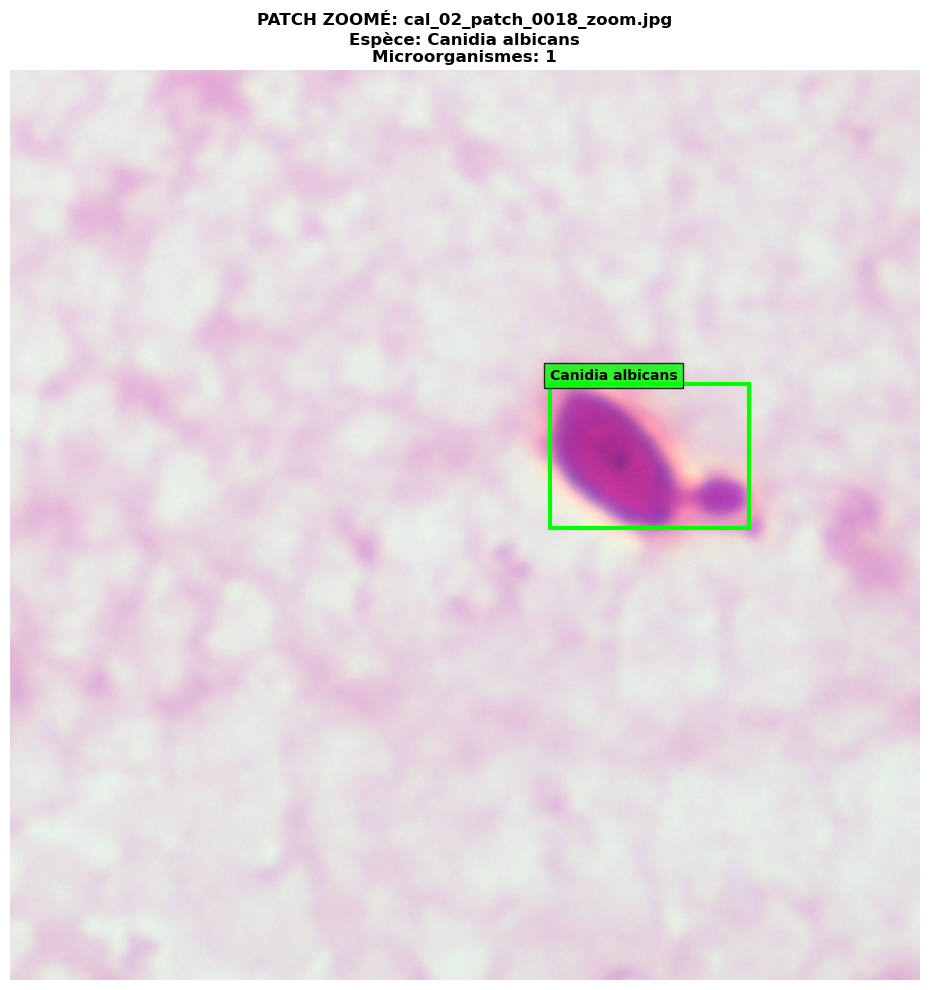

 Affiché: cal_02_patch_0018_zoom.jpg
 1 microorganismes détectés


In [16]:
import json
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
# Charger les annotations
annotations_file = "./dataset_patches_zoom/annotations_patches.json"
patches_dir = "./dataset_patches_zoom/patches"

with open(annotations_file, 'r') as f:
    data = json.load(f)

# Filtrer les images zoomées avec annotations
zoomed_images = [img for img in data['images'] 
                 if '_zoom' in img['file_name'] 
                 and img['num_annotations'] > 0]

print(f" Patches zoomés trouvés: {len(zoomed_images)}")

if len(zoomed_images) == 0:
    print(" Aucun patch zoomé trouvé!")
else:
    # Prendre une image aléatoire
    random_img = random.choice(zoomed_images)
    
    # Charger l'image
    img_path = Path(patches_dir) / random_img['file_name']
    image = Image.open(img_path)
    
    # Récupérer les annotations
    img_annotations = [ann for ann in data['annotations'] 
                      if ann['image_id'] == random_img['id']]
    
    # Afficher
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)
    ax.axis('off')
    
    # Dessiner les bounding boxes
    for ann in img_annotations:
        x, y, w, h = ann['bbox']
        rect = mpatches.Rectangle(
            (x, y), w, h,
            linewidth=3,
            edgecolor='lime',
            facecolor='none'
        )
        ax.add_patch(rect)
        
        # Label
        species = random_img['metadata']['species']
        ax.text(x, y-5, species,
               bbox=dict(facecolor='lime', alpha=0.8),
               fontsize=10, color='black', weight='bold')
    
    # Titre
    title = f"PATCH ZOOMÉ: {random_img['file_name']}\n"
    title += f"Espèce: {random_img['metadata']['species']}\n"
    title += f"Microorganismes: {len(img_annotations)}"
    ax.set_title(title, fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f" Affiché: {random_img['file_name']}")
    print(f" {len(img_annotations)} microorganismes détectés")

In [5]:
from ultralytics import YOLO
import torch
model = YOLO('yolo11l.pt')

In [1]:
import json
import shutil
from pathlib import Path
from ultralytics import YOLO
import yaml
import random

class YOLODatasetConverter:
    def __init__(self, patches_dir: str, annotations_json: str, output_dir: str):
        self.patches_dir = Path(patches_dir)
        self.annotations_json = Path(annotations_json)
        self.output_dir = Path(output_dir)
        
        with open(self.annotations_json, 'r') as f:
            self.coco_data = json.load(f)
        
        print(f"{len(self.coco_data['images'])} images")
        print(f"{len(self.coco_data['annotations'])} annotations")
        print(f"{len(self.coco_data['categories'])} catégories")
    
    def convert_bbox_coco_to_yolo(self, bbox, img_width, img_height):
        """Convertit COCO [x, y, w, h] en YOLO [x_center, y_center, w, h] normalisé"""
        x, y, w, h = bbox
        x_center = (x + w / 2) / img_width
        y_center = (y + h / 2) / img_height
        w_norm = w / img_width
        h_norm = h / img_height
        return x_center, y_center, w_norm, h_norm
    
    def create_yolo_dataset(self, train_split=0.8, val_split=0.1, 
                           empty_image_ratio=0.3, balance_dataset=True):
        """
        Crée le dataset YOLO avec équilibrage
        
        Args:
            train_split: Ratio train
            val_split: Ratio validation
            empty_image_ratio: Ratio d'images vides à garder (0.3 = 30%)
            balance_dataset: Si True, réduit le nombre d'images vides
        """
        random.seed(42)
        
        for split in ['train', 'val', 'test']:
            (self.output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
            (self.output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)
        
        # Mapping category_id -> class_id
        categories = sorted(self.coco_data['categories'], key=lambda x: x['id'])
        category_id_to_class_id = {cat['id']: idx for idx, cat in enumerate(categories)}
        
        # Grouper annotations par image
        img_id_to_anns = {}
        for ann in self.coco_data['annotations']:
            img_id = ann['image_id']
            if img_id not in img_id_to_anns:
                img_id_to_anns[img_id] = []
            img_id_to_anns[img_id].append(ann)
        
        # Séparer images avec/sans annotations
        images_with_anns = []
        images_without_anns = []
        
        for img in self.coco_data['images']:
            if img['id'] in img_id_to_anns and len(img_id_to_anns[img['id']]) > 0:
                images_with_anns.append(img)
            else:
                images_without_anns.append(img)
        
        print(f"\nANALYSE DU DATASET:")
        print(f"  Images avec microorganismes: {len(images_with_anns)}")
        print(f"  Images vides: {len(images_without_anns)}")
        print(f"  Ratio vide: {len(images_without_anns)/len(self.coco_data['images'])*100:.1f}%")
        
        # Équilibrer le dataset
        if balance_dataset:
            # Calculer combien d'images vides garder
            n_empty_to_keep = int(len(images_with_anns) * empty_image_ratio)
            random.shuffle(images_without_anns)
            images_without_anns = images_without_anns[:n_empty_to_keep]
            
            print(f"\nÉQUILIBRAGE:")
            print(f"  Images vides gardées: {len(images_without_anns)} (ratio: {empty_image_ratio*100:.0f}%)")
            print(f"  Images vides supprimées: {len(self.coco_data['images']) - len(images_with_anns) - len(images_without_anns)}")
        
        # Combiner et mélanger
        all_images = images_with_anns + images_without_anns
        random.shuffle(all_images)
        
        print(f"\nDATASET FINAL:")
        print(f"  Total images: {len(all_images)}")
        print(f"  Avec annotations: {len(images_with_anns)} ({len(images_with_anns)/len(all_images)*100:.1f}%)")
        print(f"  Vides: {len(images_without_anns)} ({len(images_without_anns)/len(all_images)*100:.1f}%)")
        
        # Split train/val/test
        n_total = len(all_images)
        n_train = int(n_total * train_split)
        n_val = int(n_total * val_split)
        
        splits = {
            'train': all_images[:n_train],
            'val': all_images[n_train:n_train + n_val],
            'test': all_images[n_train + n_val:]
        }
        
        print("\nConversion YOLO...")
        stats = {'train': {'with_anns': 0, 'empty': 0}, 
                'val': {'with_anns': 0, 'empty': 0}, 
                'test': {'with_anns': 0, 'empty': 0}}
        
        for split_name, split_images in splits.items():
            print(f"\n  {split_name.upper()}: {len(split_images)} images")
            
            for img_info in split_images:
                file_name = img_info['file_name']
                
                # Copier image
                src_img = self.patches_dir / file_name
                dst_img = self.output_dir / split_name / 'images' / file_name
                if src_img.exists():
                    shutil.copy(src_img, dst_img)
                
                # Créer label YOLO
                label_file = self.output_dir / split_name / 'labels' / f"{Path(file_name).stem}.txt"
                annotations = img_id_to_anns.get(img_info['id'], [])
                
                # Stats
                if len(annotations) > 0:
                    stats[split_name]['with_anns'] += 1
                else:
                    stats[split_name]['empty'] += 1
                
                with open(label_file, 'w') as f:
                    for ann in annotations:
                        class_id = category_id_to_class_id[ann['category_id']]
                        x_c, y_c, w, h = self.convert_bbox_coco_to_yolo(
                            ann['bbox'], img_info['width'], img_info['height']
                        )
                        f.write(f"{class_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}\n")
        
        # Créer data.yaml
        class_names = [cat['name'] for cat in categories]
        data_yaml = {
            'path': str(self.output_dir.absolute()),
            'train': 'train/images',
            'val': 'val/images',
            'test': 'test/images',
            'nc': len(class_names),
            'names': class_names
        }
        
        yaml_path = self.output_dir / 'data.yaml'
        with open(yaml_path, 'w') as f:
            yaml.dump(data_yaml, f, sort_keys=False)
        
        print("\n" + "="*60)
        print("  CONVERSION TERMINÉE!")
        print("="*60)
        for split_name, split_stats in stats.items():
            total = split_stats['with_anns'] + split_stats['empty']
            pct_anns = split_stats['with_anns'] / total * 100 if total > 0 else 0
            print(f"{split_name.capitalize()}: {total} images ({split_stats['with_anns']} avec annotations [{pct_anns:.1f}%], {split_stats['empty']} vides)")
        print(f"Classes: {len(class_names)}")
        print(f"\nYAML: {yaml_path}")
        
        return yaml_path


# UTILISATION
if __name__ == "__main__":
    
    # 1. Convertir dataset AVEC ÉQUILIBRAGE
    converter = YOLODatasetConverter(
        patches_dir="./dataset_patches_zoom/patches",
        annotations_json="./dataset_patches_zoom/annotations_patches.json",
        output_dir="./yolo_dataset_zoom_balanced"
    )
    
    yaml_path = converter.create_yolo_dataset(
        train_split=0.8, 
        val_split=0.1,
        empty_image_ratio=0.1,      # 10% d'images vides (au lieu de 70%)
        balance_dataset=True         
    )
    
    # 2. Entraîner
    model = YOLO("yolo11l.pt")  
    
    results = model.train(
        data=str(yaml_path),
        epochs=50,              
        imgsz=1024,
        batch=4,
        workers=4,
        device=0,
        scale = 0.9, 
        copy_paste = 0.2,
        # Augmentations
        mosaic=0.5,
        degrees=20,
        flipud=0.2,
        fliplr=0.5,
        hsv_h=0.015,
        hsv_s=0.4,
        hsv_v=0.4,
    )
    
    print("\n Entraînement terminé!")

17675 images
12343 annotations
57 catégories

ANALYSE DU DATASET:
  Images avec microorganismes: 5503
  Images vides: 12172
  Ratio vide: 68.9%

ÉQUILIBRAGE:
  Images vides gardées: 550 (ratio: 10%)
  Images vides supprimées: 11622

DATASET FINAL:
  Total images: 6053
  Avec annotations: 5503 (90.9%)
  Vides: 550 (9.1%)

Conversion YOLO...

  TRAIN: 4842 images



KeyboardInterrupt



In [8]:
metrics = model.val(split='test')

Ultralytics 8.3.235  Python-3.11.14 torch-2.10.0.dev20251209+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 310.952.1 MB/s, size: 140.2 KB)
val: Scanning C:\Users\othma\Desktop\micro_org\yolo_dataset_zoom_balanced\test\labels... 1595 images, 180 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1595/1595 2.8Kit/s 0.6s0.1s
val: New cache created: C:\Users\othma\Desktop\micro_org\yolo_dataset_zoom_balanced\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 1.4s/it 2:20.4ss
                   all       1595       3091      0.923      0.885       0.95      0.648
Acinetobacter baumannii         55        330      0.975      0.944      0.987      0.686
 Abiotrophia defective         43         60      0.856       0.75      0.873      0.583
       Bacillus cereus         31         36          1      0.931      0.993      0.749
   Brucella melitensis         5

In [22]:
results = model.predict(
    source="photo_Nolan/image1183.tif",
    conf=0.2,
    save=True
)


image 1/1 C:\Users\othma\Desktop\micro_org\photo_Nolan\image1183.tif: 768x1024 1 Enterococcus faecalis, 154.9ms
Speed: 8.6ms preprocess, 154.9ms inference, 1.6ms postprocess per image at shape (1, 3, 768, 1024)
Results saved to C:\Users\othma\Desktop\micro_org\runs\detect\predict


In [2]:
from sahi.predict import predict
from pathlib import Path

predict(
    model_type="yolo11",
    model_path="runs/detect/train12/weights/best.pt",
    model_confidence_threshold=0.2,
    source="images/cst_07.jpg",
    slice_height=1024,
    slice_width=1024,
    overlap_height_ratio=0.2,
)


Performing inference on images:   0%|                                                            | 0/1 [00:00<?, ?it/s]

Performing prediction on 35 slices.


Performing inference on images:   0%|                                                            | 0/1 [00:05<?, ?it/s]

Prediction time is: 4947.11 ms


Performing inference on images: 100%|████████████████████████████████████████████████████| 1/1 [00:06<00:00,  6.16s/it]

Prediction results are successfully exported to runs\predict\exp13


In [8]:
# ajout bilan des prediction 
# micro F1 metrics 
# SAM 
# Zooming croping

In [17]:
from ultralytics import YOLO

model = YOLO("runs/detect/train12/weights/best.pt")


In [1]:
from ultralytics import YOLO
import numpy as np

model = YOLO("runs/detect/train12/weights/best.pt")

results = model.val(
    data="yolo_dataset_balanced/data.yaml",
    split='test',
    conf=0.25
)

# Métriques MOYENNES (toutes classes)
print("\n" + "="*60)
print(" MÉTRIQUES GLOBALES (moyenne de toutes les classes)")
print("="*60)

precision_mean = results.box.mp
recall_mean = results.box.mr
mAP50 = results.box.map50
mAP = results.box.map

f1_mean = 2 * (precision_mean * recall_mean) / (precision_mean + recall_mean) \
          if (precision_mean + recall_mean) > 0 else 0

print(f"Precision:  {precision_mean:.3f}")
print(f"Recall:     {recall_mean:.3f}")
print(f"F1-Score:   {f1_mean:.3f}")
print(f"mAP50:      {mAP50:.3f}")
print(f"mAP50-95:   {mAP:.3f}")

# Métriques PAR CLASSE
print("\n" + "="*60)
print("F1-SCORE PAR CLASSE")
print("="*60)

# Récupérer les arrays par classe
precision_per_class = results.box.p  # Array de precision par classe
recall_per_class = results.box.r     # Array de recall par classe

# Calculer F1 par classe
f1_per_class = []
for p, r in zip(precision_per_class, recall_per_class):
    if p + r > 0:
        f1 = 2 * (p * r) / (p + r)
    else:
        f1 = 0.0
    f1_per_class.append(f1)

f1_per_class = np.array(f1_per_class)

# Trier par F1-score décroissant
sorted_indices = np.argsort(f1_per_class)[::-1]

# Afficher 
for i, idx in enumerate(sorted_indices[:60]):
    class_name = model.names[idx]
    f1 = f1_per_class[idx]
    p = precision_per_class[idx]
    r = recall_per_class[idx]
    
    print(f"{i+1:2d}. {class_name[:35]:35s} F1:{f1:.3f} (P:{p:.3f}, R:{r:.3f})")

# # Afficher classes avec F1 b
# print("\n" + "="*60)
# print("CLASSES AVEC F1 LE PLUS BAS (à améliorer)")
# print("="*60)

# for i, idx in enumerate(sorted_indices[-5:]):
#     class_name = model.names[idx]
#     f1 = f1_per_class[idx]
#     p = precision_per_class[idx]
#     r = recall_per_class[idx]
    
#     print(f"{class_name[:35]:35s} F1:{f1:.3f} (P:{p:.3f}, R:{r:.3f})")

# print("\n" + "="*60)

Ultralytics 8.3.235  Python-3.11.14 torch-2.10.0.dev20251209+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
YOLO11l summary (fused): 190 layers, 25,323,259 parameters, 0 gradients, 86.8 GFLOPs
val: Fast image access  (ping: 0.70.7 ms, read: 142.931.0 MB/s, size: 137.9 KB)
val: Scanning C:\Users\othma\Desktop\micro_org\yolo_dataset_balanced\test\labels.cache... 565 images, 131 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 565/565  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 1.4it/s 26.5s0.7ss
                   all        565       1035      0.871      0.914      0.929      0.769
Acinetobacter baumannii         18        122      0.981      0.959      0.977      0.791
 Abiotrophia defective         13         25          1      0.905      0.958      0.859
       Bacillus cereus         10         15      0.997      0.933      0.991      0.921
   Brucella melitensis         10         18          1        

In [ ]:
#transfert

In [1]:
from ultralytics import YOLO

model = YOLO("runs/detect/train9/weights/last.pt")

model.train(
    data="yolo_dataset_zoom_balanced/data.yaml",
    epochs=10,          # total epochs for the NEW run
    pretrained=True,    # continue learning from last.pt
    batch=4
)


New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.11.14 torch-2.10.0.dev20251209+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset_zoom_balanced/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train9/weights/last.pt, momentum=0.937, mosai

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002CB6ACA7D10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,